Initialization phase

In [6]:
%pip install numpy matplotlib
import numpy as np
import matplotlib.pyplot as plt
import os, time

os.makedirs('outputs', exist_ok=True)

fs = 20000
N = 1600                    
n = np.arange(N)
t = n / fs
K = N // 2 + 1
freqs = np.arange(K) * fs / N

components = [
    ('A', 1200, 10, np.pi/3),
    ('B', 3500, 15, np.pi/6),
    ('C', 5000,  8, 3*np.pi/4),
    ('D', 8500, 12, np.pi/2),
]



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.2-cp311-cp311-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.65.0-cp311-cp311-win_amd64.whl.metadata (127 kB)
  Using cached kiwisolver-1.5.1-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp311-cp311-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl (12.6 MB)
Using cached matplotlib-3.11.2-cp311-cp311-win_amd64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.65.0-cp311-cp311-win_amd64.whl (2.5 MB)
Using cached kiwisolver-1.5.1-cp311-cp311-win_amd64.whl (70 kB)
Using cached pillow-12.3.0-cp311-cp311-win_amd64.w

#### 1. Create a composite signal that consists the following frequencies and amplitudes:

##### a. 1200 Hz, 10 units, $\dfrac{\pi}{3}$

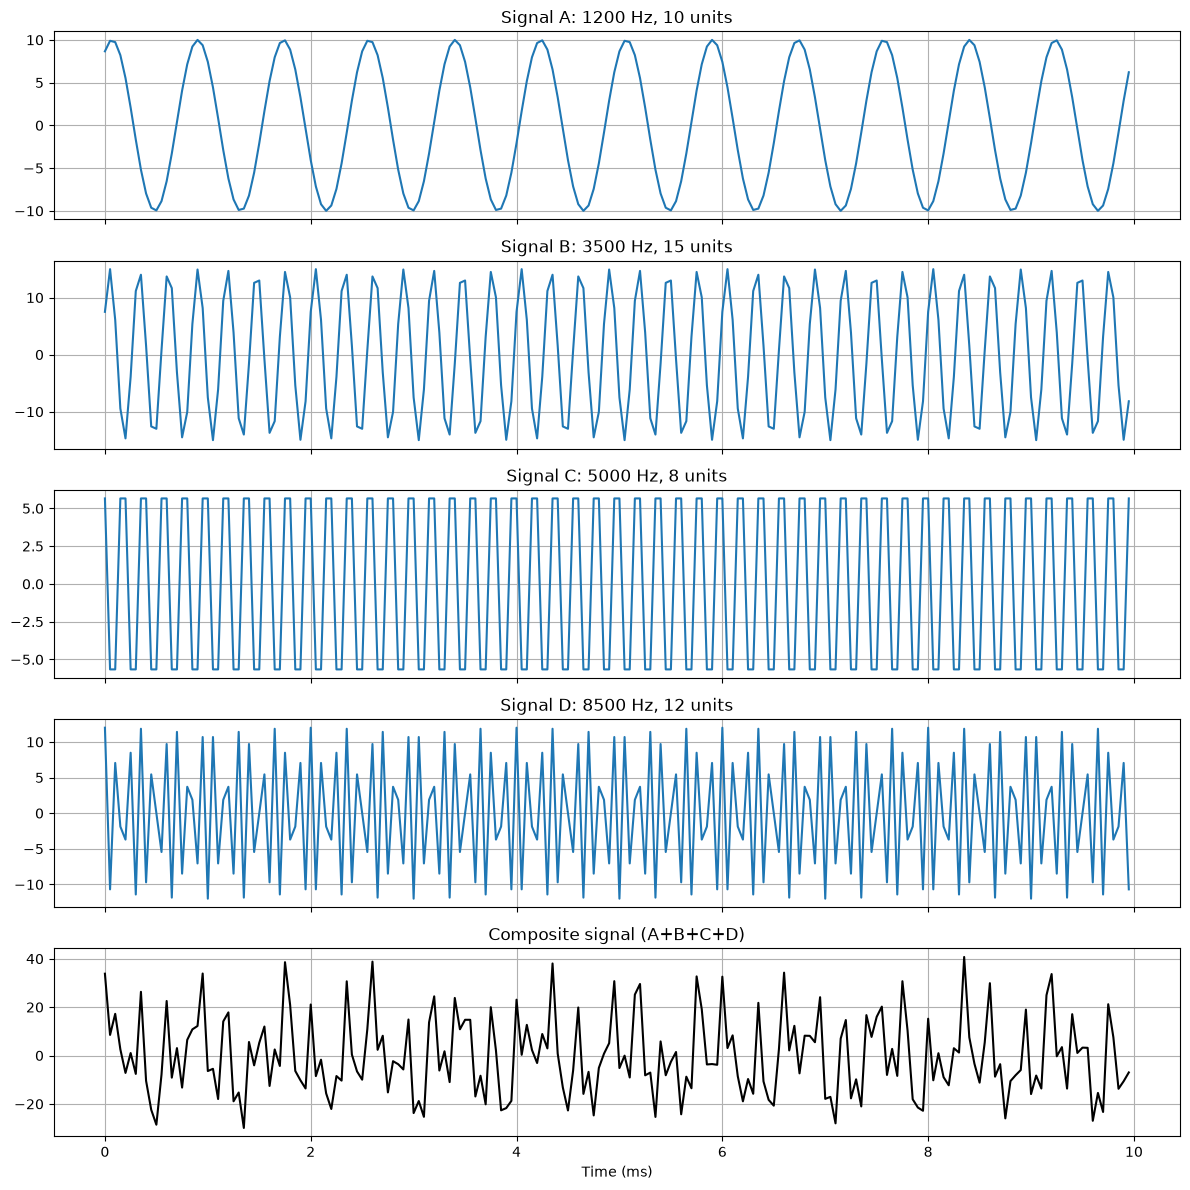

In [ ]:
parts = [A*np.sin(2*np.pi*f*t + p) for _, f, A, p in components]
composite = np.sum(parts, axis=0)

fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)
for ax, (lab, f, A, p), s in zip(axes[:4], components, parts):
    ax.plot(t[:200]*1000, s[:200])
    ax.set_title(f'Signal {lab}: {f} Hz, {A} units')
    ax.grid(True)
axes[4].plot(t[:200]*1000, composite[:200], color='black')
axes[4].set_title('Composite signal (A+B+C+D)')
axes[4].set_xlabel('Time (ms)')
axes[4].grid(True)
plt.tight_layout()
plt.savefig('outputs/part1_composite.png', dpi=150)
plt.show()


##### b. 3500 Hz, 15 units, $\dfrac{\pi}{6}$

##### c. 5000 Hz, 8 units, $\dfrac{3\pi}{4}$

##### d. 8500 Hz, 12 units, $\dfrac{\pi}{2}$

#### 2. Now, perform Discrete Fourier Transform calculation using the NumPy function, np.fft.fft. 

#### 3. Plot its frequency domain and compare the output Frequency Domain signal with Laboratory No. 9